In [14]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [15]:
df = pd.read_csv('survey_results_slim.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48019 entries, 0 to 48018
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   MainBranch                      48019 non-null  object 
 1   Age                             48019 non-null  object 
 2   Employment                      48007 non-null  object 
 3   RemoteWork                      47940 non-null  object 
 4   EdLevel                         48019 non-null  object 
 5   LearnCode                       47935 non-null  object 
 6   LearnCodeOnline                 38414 non-null  object 
 7   YearsCode                       47950 non-null  object 
 8   YearsCodePro                    47825 non-null  object 
 9   DevType                         47904 non-null  object 
 10  OrgSize                         47982 non-null  object 
 11  Country                         48019 non-null  object 
 12  LanguageHaveWorkedWith          

In [16]:
missing_pct=(df.isnull().sum()/len(df)*100).sort_values(ascending=False)
print("Missing data percentage:\n" , missing_pct[missing_pct > 50])
print ("\nTotal columns with more than 50% missing data:", (missing_pct > 50).sum())

Missing data percentage:
 AIDevHaveWorkedWith      70.969824
AIToolCurrently Using    59.286949
dtype: float64

Total columns with more than 50% missing data: 2


In [17]:
cols_to_drop = missing_pct[missing_pct >50].index.tolist()

#Add all columns to drop in one consolidated list 
cols_to_drop.extend([
    #Less critical columns
    'LearnCodeOnline', 'OpSysPersonal use',

    #Meta columns
    'ICorPM', 'ProfessionalTech', 'TBranch',

    #High missingness tech columns 
    'AISearchHaveWorkedWith', #38.6% missing
    'MiscTechHaveWorkedWith', #33.8% missing

    # Office tools - less relevant 
    'OfficeStackAsyncHaveWorkedWith',
    'OfficeStackSyncHaveWorkedWith',
    'NEWCollabToolsHaveWorkedWith'
])

#Remove deplicates and drop
cols_to_drop = list(set(cols_to_drop))
df_cleaned = df.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns")
print (f"Remaining columns: {df_cleaned.shape[1]}")
print(f"\nRemaining columns: \n{df_cleaned.columns}")


Dropped 12 columns
Remaining columns: 21

Remaining columns: 
Index(['MainBranch', 'Age', 'Employment', 'RemoteWork', 'EdLevel', 'LearnCode',
       'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'Country',
       'LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith',
       'PlatformHaveWorkedWith', 'WebframeHaveWorkedWith',
       'ToolsTechHaveWorkedWith', 'OpSysProfessional use', 'AISelect',
       'WorkExp', 'Industry', 'ConvertedCompYearly'],
      dtype='object')


In [18]:
df_cleaned.head()

,MainBranch,Age,Employment,RemoteWork,EdLevel,LearnCode,YearsCode,YearsCodePro,DevType,OrgSize,...,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,ToolsTechHaveWorkedWith,OpSysProfessional use,AISelect,WorkExp,Industry,ConvertedCompYearly
0,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Friend or fam...,18,9,"Senior Executive (C-Suite, VP, etc.)",2 to 9 employees,...,HTML/CSS;JavaScript;Python,Supabase,Amazon Web Services (AWS);Netlify;Vercel,Next.js;React;Remix;Vue.js,Docker;Kubernetes;npm;Pip;Vite;Webpack;Yarn,MacOS;Windows;Windows Subsystem for Linux (WSL),Yes,10.0,"Information Services, IT, Software Development...",285000.0
1,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,27,23,"Developer, back-end","5,000 to 9,999 employees",...,Bash/Shell (all shells);Go,NaN,Amazon Web Services (AWS);Google Cloud;OpenSta...,NaN,Cargo;Docker;Kubernetes;Make;Nix,MacOS;Other Linux-based,"No, and I don't plan to",23.0,"Information Services, IT, Software Development...",250000.0
2,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Colleague;Friend or family member;Other online...,12,7,"Developer, front-end",100 to 499 employees,...,Bash/Shell (all shells);HTML/CSS;JavaScript;PH...,PostgreSQL;Redis,Cloudflare;Heroku,Node.js;React;Ruby on Rails;Vue.js;WordPress,Homebrew;npm;Vite;Webpack;Yarn,iOS;iPadOS;MacOS,"No, and I don't plan to",7.0,NaN,156000.0
3,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...",Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Online Courses or Certi...,6,4,"Developer, full-stack",20 to 99 employees,...,HTML/CSS;JavaScript;TypeScript,BigQuery;Elasticsearch;MongoDB;PostgreSQL,Amazon Web Services (AWS);Firebase;Heroku;Netl...,Express;Gatsby;NestJS;Next.js;Node.js;React,Docker;npm;Webpack;Yarn,Other (Please Specify):,Yes,6.0,Other,23456.0
4,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Some college/university study without earning ...,Books / Physical media;Colleague;Online Course...,21,21,"Developer, back-end",100 to 499 employees,...,Bash/Shell (all shells);HTML/CSS;JavaScript;Ru...,BigQuery;Cloud Firestore;PostgreSQL;Redis,Amazon Web Services (AWS);Cloudflare;Google Cloud,Angular;Express;NestJS;Node.js,Docker;Homebrew;Kubernetes;npm;pnpm;Terraform,MacOS,Yes,22.0,Other,96828.0


In [19]:
# Check remaining missing data in your filtered dataset
print ("Missing data in remaining columns:")
missing_after = (df_cleaned.isnull().sum() / len(df_cleaned)*100).sort_values(ascending=False)
print (missing_after[missing_after>0])

Missing data in remaining columns:
Industry                   42.216623
WorkExp                    32.031071
PlatformHaveWorkedWith     22.166226
WebframeHaveWorkedWith     21.145796
DatabaseHaveWorkedWith     13.026094
ToolsTechHaveWorkedWith     8.255066
OpSysProfessional use       6.224619
YearsCodePro                0.404007
LanguageHaveWorkedWith      0.283221
DevType                     0.239489
LearnCode                   0.174931
RemoteWork                  0.164518
YearsCode                   0.143693
OrgSize                     0.077053
Employment                  0.024990
dtype: float64


In [20]:
print ("\nData Types:")
print(df_cleaned.dtypes.value_counts())


Data Types:
object     19
float64     2
Name: count, dtype: int64


In [21]:
print ("\nUnique values in key columns:")
for col in ['Country', 'DevType', 'EDLevel', 'Employment']:
    if col in df_cleaned.columns:
        print (f"{col}: {df_cleaned[col].nunique()} unique values")


Unique values in key columns:
Country: 171 unique values
DevType: 33 unique values
Employment: 14 unique values


In [22]:
#After droppiing your high missing columns, just do:
df_model=df_cleaned.dropna().copy()

print (f"Final dataset shape: {df_model.shape}")
print(f"Rows retained: {len(df_model)} ({len(df_model)/48019 *100:.1f}% of filtered data)")

Final dataset shape: (16460, 21)
Rows retained: 16460 (34.3% of filtered data)


In [23]:
# Check your target variable distribution 
print ("\nSalary statistics:")
print(df_model['ConvertedCompYearly'].describe())

#Check for outliers 
print(f"\nSalaries > $500k: {(df_model['ConvertedCompYearly']>500000).sum()}")
print(f"Salaries < $10k: {(df_model['ConvertedCompYearly']>10000).sum()}")


Salary statistics:
count    1.646000e+04
mean     9.412425e+04
std      1.309772e+05
min      1.000000e+00
25%      4.362100e+04
50%      7.496300e+04
75%      1.231530e+05
max      1.031937e+07
Name: ConvertedCompYearly, dtype: float64

Salaries > $500k: 51
Salaries < $10k: 15353


In [24]:
# Check the extreme values 
print ("Top 10 salaries:")
display(df_model.nlargest(10, 'ConvertedCompYearly')[['Country', 'DevType', 'YearsCodePro', 'ConvertedCompYearly']])

print ("\nBottom  10 salaries:")
display(df_model.nsmallest(10,'ConvertedCompYearly')[['Country', 'DevType', 'YearsCodePro', 'ConvertedCompYearly']])

Top 10 salaries:


,Country,DevType,YearsCodePro,ConvertedCompYearly
45679,New Zealand,Engineering manager,40,10319366.0
20505,Canada,"Developer, full-stack",2,7435143.0
44175,Brazil,"Developer, full-stack",22,4451577.0
44794,Brazil,"Developer, mobile",4,2028761.0
29024,United States of America,"Developer, back-end",18,1800000.0
4394,Japan,Other (please specify):,23,1792064.0
30077,United States of America,Other (please specify):,4,1250000.0
38087,Germany,"Developer, back-end",22,1069822.0
24801,Canada,"Developer, full-stack",5,929393.0
41471,Sweden,Data scientist or machine learning specialist,4,921414.0



Bottom  10 salaries:


,Country,DevType,YearsCodePro,ConvertedCompYearly
1192,India,"Developer, full-stack",11,1.0
4861,Viet Nam,"Developer, full-stack",3,1.0
10078,China,"Developer, front-end",2,1.0
21795,Uganda,"Developer, desktop or enterprise applications",5,1.0
6073,Syrian Arab Republic,"Developer, front-end",2,2.0
8307,"Iran, Islamic Republic of...","Developer, back-end",25,2.0
11842,Hungary,"Developer, mobile",30,2.0
24100,Indonesia,"Developer, full-stack",3,2.0
27998,United Republic of Tanzania,"Developer, front-end",1,2.0
35753,Uzbekistan,"Developer, front-end",3,2.0



After salary filtering:
Rows: 15309
Salary range: $10,000 - $ 500,000

New salary statistics:
count     15309.000000
mean      97043.815925
std       67251.276938
min       10000.000000
25%       50332.000000
50%       80317.000000
75%      128507.000000
max      500000.000000
Name: ConvertedCompYearly, dtype: float64


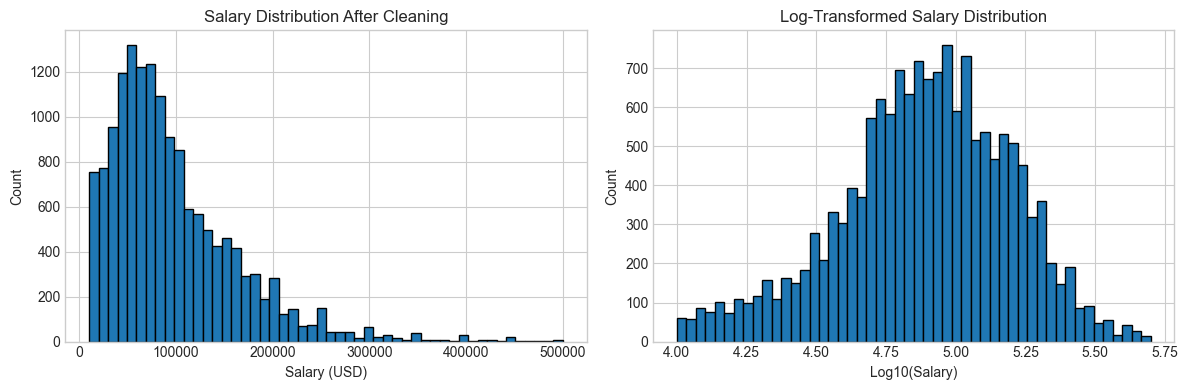

In [25]:
df_model = df_model[
    (df_model['ConvertedCompYearly'] >= 10000)&
    (df_model['ConvertedCompYearly']<=500000)
    ]

print (f"\nAfter salary filtering:")
print(f"Rows: {len(df_model)}")
print (f"Salary range: ${df_model['ConvertedCompYearly'].min():,.0f} - $ {df_model['ConvertedCompYearly'].max():,.0f}")
print (f"\nNew salary statistics:")
print(df_model['ConvertedCompYearly'].describe())

#Visualize the distribution 

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(df_model['ConvertedCompYearly'], bins=50, edgecolor='black')
plt.xlabel('Salary (USD)')
plt.ylabel('Count')
plt.title('Salary Distribution After Cleaning')

plt.subplot(1,2,2)
plt.hist(np.log10(df_model['ConvertedCompYearly']), bins=50, edgecolor='black')
plt.xlabel('Log10(Salary)')
plt.ylabel('Count')
plt.title('Log-Transformed Salary Distribution')

plt.tight_layout()
plt.show()

In [26]:
#Count features for all tech stack columns 
print("Creating count features for multi-select columns..")

# Languages
df_model['Num_Languages']=df_model['LanguageHaveWorkedWith'].str.count(';')+1

#Databases
df_model['Num_Databases']=df_model['DatabaseHaveWorkedWith'].str.count(';')+1

#Platforms
df_model['Num_Platforms']=df_model['PlatformHaveWorkedWith'].str.count(';')+1

# Web Frameworks
df_model['Num_Webframes']=df_model['WebframeHaveWorkedWith'].str.count(';')+1

#Tools/Tech
df_model['Num_Tools']=df_model['ToolsTechHaveWorkedWith'].str.count(';')+1

#Check the new features 
print("\nCount feature statistics:")
count_cols = ['Num_Languages', 'Num_Databases', 'Num_Platforms', 'Num_Webframes', 'Num_Tools']
display(df_model[count_cols].describe())

#Create a "total skills" feature
df_model['Total_Skills'] =(
    df_model['Num_Languages']+
    df_model['Num_Databases']+
    df_model['Num_Platforms']+
    df_model['Num_Webframes']+
    df_model['Num_Tools']
)

print ("\nTotal Skills distribution:")
print(df_model['Total_Skills'].describe())

#Quick correlation check with salary 
print("\nCorrelation with salary:")
correlation_data = df_model[count_cols + ['Total_Skills', 'ConvertedCompYearly']].corr()['ConvertedCompYearly'].sort_values(ascending=False)
print (correlation_data) 

Creating count features for multi-select columns..

Count feature statistics:


,Num_Languages,Num_Databases,Num_Platforms,Num_Webframes,Num_Tools
count,15309.000000,15309.000000,15309.000000,15309.000000,15309.000000
mean,5.888366,3.409890,2.412698,3.691097,5.575805
std,2.918188,2.176719,1.643505,2.409808,3.192943
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,4.000000,2.000000,1.000000,2.000000,3.000000
50%,5.000000,3.000000,2.000000,3.000000,5.000000
75%,7.000000,4.000000,3.000000,5.000000,7.000000
max,41.000000,30.000000,17.000000,32.000000,37.000000



Total Skills distribution:
count    15309.000000
mean        20.977856
std          9.170052
min          5.000000
25%         15.000000
50%         19.000000
75%         25.000000
max        140.000000
Name: Total_Skills, dtype: float64

Correlation with salary:
ConvertedCompYearly    1.000000
Num_Tools              0.114356
Num_Languages          0.074025
Total_Skills           0.044754
Num_Platforms          0.006805
Num_Databases         -0.003100
Num_Webframes         -0.072698
Name: ConvertedCompYearly, dtype: float64


In [27]:
#Explore what languages/skill are most common 
print ("Top 20 languages:")
all_langs=df_model['LanguageHaveWorkedWith'].str.split(';').explode()
print(all_langs.value_counts().head(20))

print("\nTop 15 databases:")
all_dbs=df_model['DatabaseHaveWorkedWith'].str.split(';').explode()
print(all_dbs.value_counts().head(15))

print("\nTop 15 platforms:")
all_platforms = df_model['PlatformHaveWorkedWith'].str.split(';').explode()
print(all_platforms.value_counts().head(15))

Top 20 languages:
LanguageHaveWorkedWith
JavaScript                 11851
SQL                         9565
HTML/CSS                    9423
TypeScript                  8868
Python                      7193
Bash/Shell (all shells)     6042
C#                          5108
Java                        4645
PHP                         3059
Go                          2840
PowerShell                  2747
C++                         2028
Rust                        1988
C                           1691
Kotlin                      1635
Ruby                        1538
Dart                         909
Lua                          857
Groovy                       758
Swift                        704
Name: count, dtype: int64

Top 15 databases:
DatabaseHaveWorkedWith
PostgreSQL                    8827
MySQL                         6112
Redis                         4865
Microsoft SQL Server          4599
SQLite                        4586
MongoDB                       4273
Elasticsearch        

In [28]:
# === LANGUAGES ===
# High-paying/specialized languages
df_model['Has_Rust']=df_model['LanguageHaveWorkedWith'].str.contains('Rust',na=False).astype(int)
df_model['Has_Go']=df_model['LanguageHaveWorkedWith'].str.contains('Go',na=False).astype(int)
df_model['Has_Scala']=df_model['LanguageHaveWorkedWith'].str.contains('Scala',na=False).astype(int)
df_model['Has_Kotlin']=df_model['LanguageHaveWorkedWith'].str.contains('Kotlin',na=False).astype(int)
df_model['Has_Swift']=df_model['LanguageHaveWorkedWith'].str.contains('Swift',na=False).astype(int)

#Popular/versatile languages
df_model['Has_Python']=df_model['LanguageHaveWorkedWith'].str.contains('Python',na=False).astype(int)
df_model['Has_JavaScript']=df_model['LanguageHaveWorkedWith'].str.contains('JavaScript',na=False).astype(int)
df_model['Has_TypeScript']=df_model['LanguageHaveWorkedWith'].str.contains('TypeScript',na=False).astype(int)
df_model['Has_Java']=df_model['LanguageHaveWorkedWith'].str.contains('Java',na=False).astype(int)
df_model['Has_CSharp']=df_model['LanguageHaveWorkedWith'].str.contains('C#',na=False).astype(int)
df_model['Has_SQL']=df_model['LanguageHaveWorkedWith'].str.contains('SQL',na=False).astype(int)

# === DATABASES ===
df_model['Has_PostgreSQL']=df_model['DatabaseHaveWorkedWith'].str.contains('PostgreSQL',na=False).astype(int)
df_model['Has_MongoDB']=df_model['DatabaseHaveWorkedWith'].str.contains('MongoDB',na=False).astype(int)
df_model['Has_Redis']=df_model['DatabaseHaveWorkedWith'].str.contains('Redis',na=False).astype(int)
df_model['Has_Elasticsearch']=df_model['DatabaseHaveWorkedWith'].str.contains('Elasticsearch',na=False).astype(int)

# === CLOUD PLATFORMS ===
df_model['Has_AWS']=df_model['PlatformHaveWorkedWith'].str.contains('Amazon Web Services|AWS',na=False).astype(int)
df_model['Has_Azure']=df_model['PlatformHaveWorkedWith'].str.contains('Azure',na=False).astype(int)
df_model['Has_GCP']=df_model['PlatformHaveWorkedWith'].str.contains('Google Cloud',na=False).astype(int)

# === WEB FRAMEWORKS (modern ones tend to pay better ) ===
df_model['Has_React']=df_model['WebframeHaveWorkedWith'].str.contains('React',na=False).astype(int)
df_model['Has_NextJS']=df_model['WebframeHaveWorkedWith'].str.contains('Next.js',na=False).astype(int)
df_model['Has_NodeJS']=df_model['WebframeHaveWorkedWith'].str.contains('Node.js',na=False).astype(int)
df_model['Has_SpringBoot']=df_model['WebframeHaveWorkedWith'].str.contains('Spring Boot',na=False).astype(int)


# === DEVOPS/INFRASTRUCTURE TOOLS (these should correlate well) ===
df_model['Has_Docker']=df_model['ToolsTechHaveWorkedWith'].str.contains('Docker',na=False).astype(int)
df_model['Has_Kubernetes']=df_model['ToolsTechHaveWorkedWith'].str.contains('Kubernetes',na=False).astype(int)
df_model['Has_Terraform']=df_model['ToolsTechHaveWorkedWith'].str.contains('Terraform',na=False).astype(int)

skill_features = [col for col in df_model.columns if col.startswith('Has_')]
skill_corr = df_model[skill_features + ['ConvertedCompYearly']].corr()['ConvertedCompYearly'].sort_values(ascending=False)

print("=== ALL Skill Correlations (sorted) ===")
print(skill_corr[skill_corr.index != 'ConvertedCompYearly'])

#Now drop the original string columns AND the count features
cols_to_drop_final = [
    'LanguageHaveWorkedWith',
    'DatabaseHaveWorkedWith',
    'PlatformHaveWorkedWith',
    'WebframeHaveWorkedWith',
    'ToolsTechHaveWorkedWith',
    # Drop count features since binary features are better 
    'Num_Languages',
    'Num_Databases',
    'Num_Platforms',
    'Num_Webframes',
    'Num_Tools',
    'Total_Skills'
]
df_model = df_model.drop(columns=cols_to_drop_final)

print(f"\nFinal shape with binary skill features: {df_model.shape}")
print(f"\nFeature types:")
print(df_model.dtypes.value_counts())


=== ALL Skill Correlations (sorted) ===
Has_Terraform        0.177524
Has_AWS              0.142293
Has_Kubernetes       0.128906
Has_Go               0.123166
Has_Rust             0.082603
Has_Python           0.079271
Has_Docker           0.064240
Has_Redis            0.061930
Has_React            0.061303
Has_Elasticsearch    0.053530
Has_PostgreSQL       0.049394
Has_Scala            0.046563
Has_TypeScript       0.037359
Has_GCP              0.035238
Has_Swift            0.023807
Has_Kotlin           0.014656
Has_SQL              0.005919
Has_Azure           -0.014817
Has_JavaScript      -0.015086
Has_NextJS          -0.017373
Has_Java            -0.017985
Has_CSharp          -0.020396
Has_NodeJS          -0.024481
Has_SpringBoot      -0.035489
Has_MongoDB         -0.095041
Name: ConvertedCompYearly, dtype: float64

Final shape with binary skill features: (15309, 41)

Feature types:
int64      25
object     14
float64     2
Name: count, dtype: int64


In [29]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15309 entries, 0 to 48017
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   MainBranch             15309 non-null  object 
 1   Age                    15309 non-null  object 
 2   Employment             15309 non-null  object 
 3   RemoteWork             15309 non-null  object 
 4   EdLevel                15309 non-null  object 
 5   LearnCode              15309 non-null  object 
 6   YearsCode              15309 non-null  object 
 7   YearsCodePro           15309 non-null  object 
 8   DevType                15309 non-null  object 
 9   OrgSize                15309 non-null  object 
 10  Country                15309 non-null  object 
 11  OpSysProfessional use  15309 non-null  object 
 12  AISelect               15309 non-null  object 
 13  WorkExp                15309 non-null  float64
 14  Industry               15309 non-null  object 
 15  Convert

In [30]:
#Check remaining categorical columns 
categorical_cols=df_model.select_dtypes(include='object').columns.tolist()

print("Remaining categorical columns:")
for col in categorical_cols:
    n_unique=df_model[col].nunique()
    print(f"\n{col}: {n_unique} unique values")
    if n_unique <= 20:
        print(df_model[col].value_counts())
    else:
        print(f"Top 10:\n{df_model[col].value_counts().head(10)}")

Remaining categorical columns:

MainBranch: 2 unique values
MainBranch
I am a developer by profession                                                           14757
I am not primarily a developer, but I write code sometimes as part of my work/studies      552
Name: count, dtype: int64

Age: 8 unique values
Age
25-34 years old       7575
35-44 years old       4552
18-24 years old       1450
45-54 years old       1326
55-64 years old        357
65 years or older       35
Under 18 years old       7
Prefer not to say        7
Name: count, dtype: int64

Employment: 10 unique values
Employment
Employed, full-time                                                                             12724
Employed, full-time;Independent contractor, freelancer, or self-employed                         1412
Independent contractor, freelancer, or self-employed                                              787
Employed, part-time                                                                               

In [31]:
# === 1. Drop: Too complex to be useful ===
# LearnCode has 554 combinations - not useful for prediction 
# OpSysProfessional use has 947 combinations - too fragmented 
df_model = df_model.drop(columns=['LearnCode', 'OpSysProfessional use'])

age_order={
    'Under 18 years old':0,
    '18-24 years old':1,
    '25-34 years old':2,
    '35-44 years old':3,
    '45-54 years old':4,
    '55-64 years old':5,
    '65 years or older':6,
    'Prefer not to say':2, # Assign to middle age as neutral 
}

df_model['Age_Ordinal']=df_model['Age'].map(age_order)
df_model= df_model.drop(columns=['Age'])

#Edlevel - clear ordinal relationship 
edlevel_order={
    'Primary/elementary school':0,
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)':1,
    'Some college/university study without earning a degree':2,
    'Associate degree (A.A., A.S., etc.)':3,
    'Bachelor’s degree (B.A., B.S., B.Eng., etc.)':4,
    'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)':5,
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)':6,
    'Something else':2 #Assign to some college neutral

}

df_model['EdLevel_Ordinal']=df_model['EdLevel'].map(edlevel_order)
df_model=df_model.drop(columns=['EdLevel'])

#OrgSize - ordinal encoding (size matters)
orgsize_order={
    'Just me - I am a freelancer, sole proprietor, etc.':0,
    '2 to 9 employees':1,
    '10 to 19 employees':2,
    '20 to 99 employees':3,
    '100 to 499 employees':4,
    '500 to 999 employees':5,
    '1,000 to 4,999 employees':6,
    '5,000 to 9,999 employees':7,
    '10,000 or more employees':8,
    'I don’t know':4 # Assign to middle as neutral
}
df_model['OrgSize_Ordinal']=df_model['OrgSize'].map(orgsize_order)
df_model=df_model.drop(columns=['OrgSize'])

# == 3. SIMPLIFY: Employment (consolidate rare categories) ===
def simplify_employment(emp):
    if pd.isna(emp):
        return 'Unknown'
    elif 'Employed, full-time' in emp and 'Independent contractor' in emp:
        return 'Full-time + Freelance'
    elif 'Employed, full-time' in emp:
        return 'Full-time'
    elif 'Independent contractor' in emp or 'freelancer' in emp or 'self-employed' in emp:
        return 'Freelance'
    elif 'part-time' in emp:
        return 'Part-time'
    else:
        return 'Other'

df_model['Employment_Simple']=df_model['Employment'].apply(simplify_employment)
df_model = df_model.drop(columns=['Employment'])
print ("\nSimplified Employment:")
print(df_model['Employment_Simple'].value_counts())

# === 4. ONE-HOT Encode :  Low cardinality ===
#MainBranch (2 unique), RemoteWork (3), AISelect(3), Industry(12)
one_hot_cols=['MainBranch', 'RemoteWork','AISelect','Employment_Simple']

for col in one_hot_cols:
    dummies = pd.get_dummies(df_model[col],prefix=col,drop_first=True)
    df_model=pd.concat([df_model, dummies], axis=1)
    df_model = df_model.drop(columns=[col])

#Industry - one-hot encode 
industry_dummies=pd.get_dummies(df_model['Industry'],prefix='Industry',drop_first=True)
df_model=pd.concat([df_model, industry_dummies], axis=1)
df_model = df_model.drop(columns=['Industry'])

# === 5.Numeric: Already numeric, keep as-is ===
#YearsCode, YearCodePro, WorkExp - just convert to numeric 
df_model['YearsCode']=pd.to_numeric(df_model['YearsCode'], errors='coerce')
df_model['YearsCodePro']=pd.to_numeric(df_model['YearsCodePro'], errors='coerce')

print("\nNumeric columns check:")
print(df_model[['YearsCode','YearsCodePro','WorkExp']].describe())

# === 6. Handle High Cardinality ===
#DevType(33 unique) - keep top 10, group rest as "Other"
top_10_devtypes=df_model['DevType'].value_counts().head(10).index
df_model['DevType_Grouped']=df_model['DevType'].apply(
    lambda x: x if x in top_10_devtypes else 'Other'
)
devtype_dummies =pd.get_dummies(df_model['DevType_Grouped'], prefix='DevType', drop_first=True)
df_model=pd.concat([df_model,devtype_dummies],axis=1)
df_model = df_model.drop(columns=['DevType','DevType_Grouped'])

#Country (140 unique) - keep top 15,group rest as "Other"
top_15_countries = df_model['Country'].value_counts().head(15).index
df_model['Country_Grouped']=df_model['Country'].apply(
    lambda x: x if x in top_15_countries else 'Other'
)
country_dummies = pd.get_dummies(df_model['Country_Grouped'],prefix='Country', drop_first=True)
df_model=pd.concat([df_model, country_dummies],axis=1)
df_model=df_model.drop(columns=['Country','Country_Grouped'])

print(f"\nColumn types:")
print(df_model.dtypes.value_counts())
print(f"\nAll numeric? {df_model.select_dtypes(include='object').shape[1] ==0}")

#Check for any remaining nulls
print(f"\nRemaining nulls:")
null_counts=df_model.isnull().sum()
print(null_counts[null_counts >0])


Simplified Employment:
Employment_Simple
Full-time                12776
Full-time + Freelance     1462
Freelance                  866
Part-time                  205
Name: count, dtype: int64

Numeric columns check:
          YearsCode  YearsCodePro       WorkExp
count  15289.000000  15073.000000  15309.000000
mean      15.429394     10.708286     11.621073
std        8.859019      7.684437      8.334593
min        1.000000      1.000000      0.000000
25%        9.000000      5.000000      5.000000
50%       13.000000      9.000000     10.000000
75%       20.000000     15.000000     16.000000
max       50.000000     50.000000     50.000000

Column types:
bool       44
int64      28
float64     4
Name: count, dtype: int64

All numeric? True

Remaining nulls:
YearsCode        20
YearsCodePro    236
dtype: int64


In [32]:
df_model = df_model.dropna()

In [33]:
df_model.head()

,YearsCode,YearsCodePro,WorkExp,ConvertedCompYearly,Has_Rust,Has_Go,Has_Scala,Has_Kotlin,Has_Swift,Has_Python,...,Country_Italy,Country_Netherlands,Country_Other,Country_Poland,Country_Portugal,Country_Spain,Country_Sweden,Country_Switzerland,Country_United Kingdom of Great Britain and Northern Ireland,Country_United States of America
0,18.0,9.0,10.0,285000.0,0,0,0,0,0,1,...,False,False,False,False,False,False,False,False,False,True
3,6.0,4.0,6.0,23456.0,0,0,0,0,0,0,...,False,False,True,False,False,False,False,False,False,False
4,21.0,21.0,22.0,96828.0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
5,4.0,3.0,4.0,135000.0,0,1,1,0,1,0,...,False,False,False,False,False,False,False,False,False,True
6,5.0,3.0,5.0,80000.0,1,1,0,0,0,1,...,False,False,False,False,False,False,False,False,False,True


In [34]:
df_model = df_model.dropna()

print (f"\nShape after dropping nulls: {df_model.shape}")
print(f"Rows lost: {15309 - len(df_model)}")
print(f"Percentage retained: {len(df_model)/15309*100:.1f}%")

#Verify completely clean 
print(f"\nRemaining nulls: {df_model.isnull().sum().sum()}")
print(f"All numeric/boolean? {df_model.select_dtypes(include='object').shape[1] ==0}")

print(f"\n === FINAL CLEAN DATASET ===")
print(f"Rows: {len(df_model)}")
print(f"Columns: {df_model.shape[1]}")
print(f"Features: {df_model.shape[1]-1}")
print(f"Target: ConvertedCompYearly")


Shape after dropping nulls: (15062, 76)
Rows lost: 247
Percentage retained: 98.4%

Remaining nulls: 0
All numeric/boolean? True

 === FINAL CLEAN DATASET ===
Rows: 15062
Columns: 76
Features: 75
Target: ConvertedCompYearly


## ML Modeling

In [35]:
#Separate features and target 
x= df_model.drop(columns=['ConvertedCompYearly'])
y=df_model['ConvertedCompYearly']

print(f"Features shape: {x.shape}")
print(f"Target shape: {y.shape}")

Features shape: (15062, 75)
Target shape: (15062,)



=== TOP 20 POSITIVE CORRELATIONS WITH SALARY ===
Country_United States of America                0.600421
YearsCodePro                                    0.311397
WorkExp                                         0.306474
YearsCode                                       0.303384
Age_Ordinal                                     0.259012
OrgSize_Ordinal                                 0.210984
Has_Terraform                                   0.176216
RemoteWork_Remote                               0.142750
Has_AWS                                         0.139944
Has_Kubernetes                                  0.125388
Has_Go                                          0.121989
DevType_Engineering manager                     0.108188
DevType_Senior Executive (C-Suite, VP, etc.)    0.097300
Has_Rust                                        0.084896
Has_Python                                      0.081630
Has_React                                       0.064418
Has_Docker                            

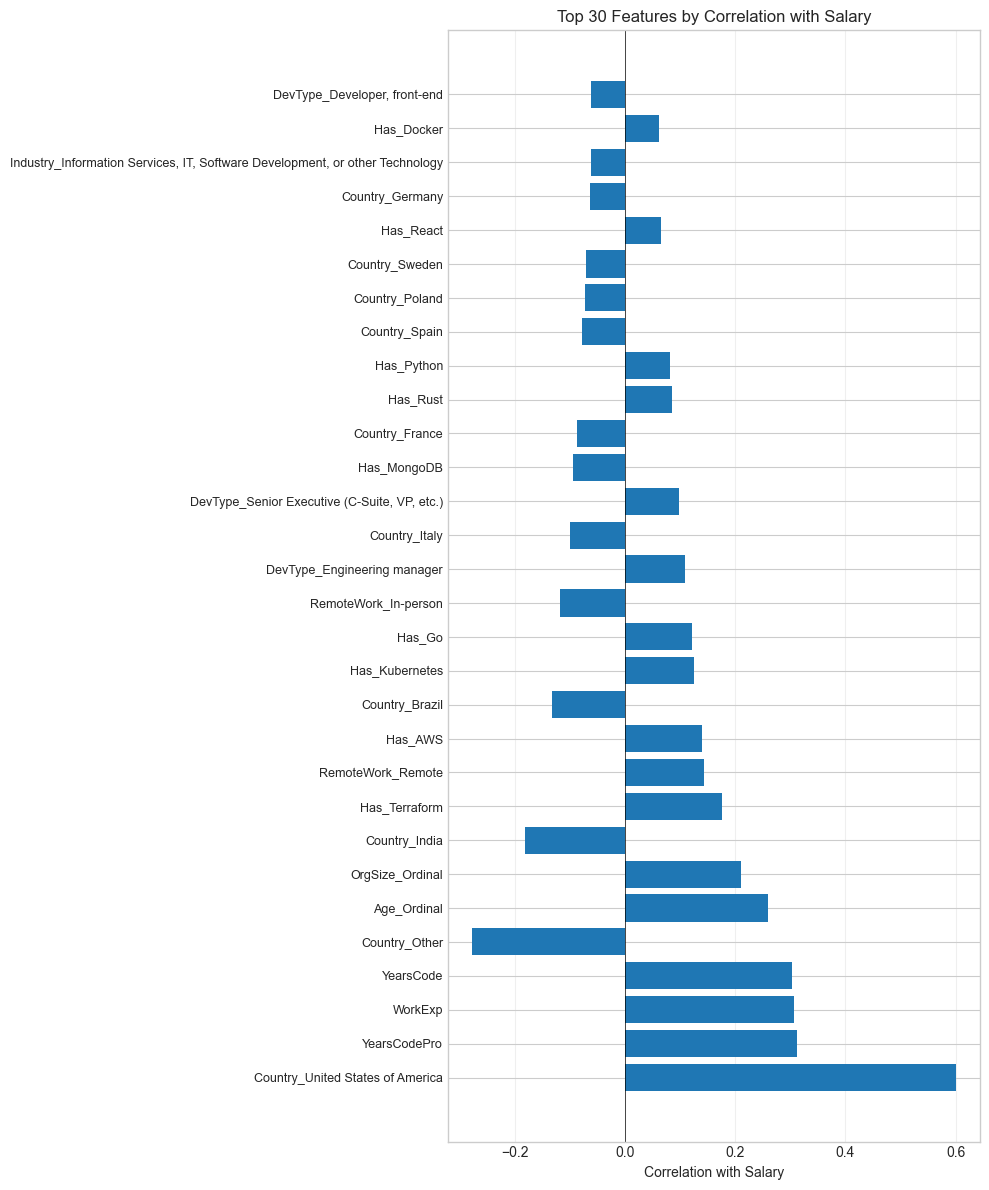

In [36]:
#Calculate correlation with target 
correlations=x.corrwith(y).sort_values(ascending=False)

print("\n=== TOP 20 POSITIVE CORRELATIONS WITH SALARY ===")
print(correlations.head(20))

print("\n=== TOP 20 NEGATIVE CORRELATIONS WITH SALARY ===")
print(correlations.tail(20))

#Visualize top correlations
plt.figure(figsize=(10,12))

#Get top 30 features by absolute correlation
top_features = correlations.abs().sort_values(ascending=False).head(30)
top_correlations= correlations[top_features.index]

plt.barh(range(len(top_correlations)), top_correlations.values)
plt.yticks(range(len(top_correlations)), top_correlations.index, fontsize=9)
plt.xlabel('Correlation with Salary')
plt.title('Top 30 Features by Correlation with Salary')
plt.axvline(x=0,color='black',linestyle='-',linewidth=0.5)
plt.grid(axis='x',alpha=0.3)
plt.tight_layout()
plt.show()


=== Checking for Multicollinearity ===

Highly correlated feature pairs(>0.8):
YearsCodePro <-> WorkExp: 0.928
YearsCodePro <-> YearsCode: 0.906
YearsCodePro <-> Age_Ordinal: 0.801
WorkExp <-> YearsCode: 0.861
WorkExp <-> Age_Ordinal: 0.826


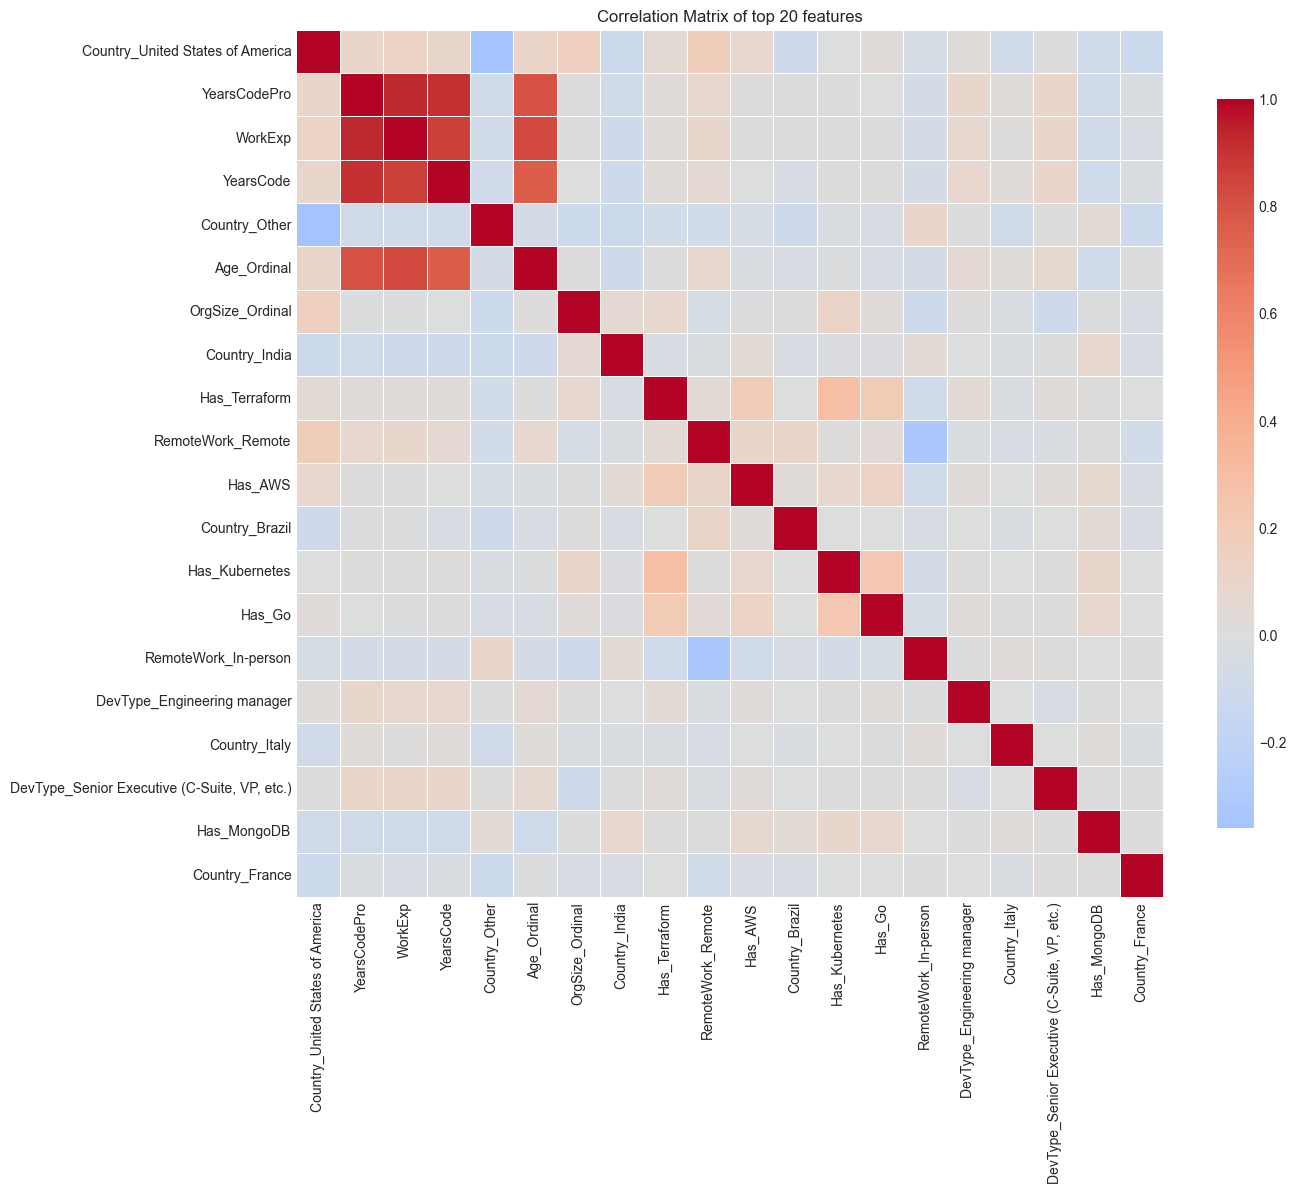

In [37]:
#Check for multicollinearity among top features 
print("\n=== Checking for Multicollinearity ===")
top_20_features = correlations.abs().sort_values(ascending=False).head(20).index.tolist()

#Correlation matrix of top features 
feature_corr =x[top_20_features].corr()

#Find highly correlated feature pairs(>0.8)
high_corr_pairs=[]
for i in range(len(feature_corr.columns)):
    for j in range(i+1, len(feature_corr.columns)):
        if abs(feature_corr.iloc[i,j])>0.8:
            high_corr_pairs.append((feature_corr.columns[i],feature_corr.columns[j],feature_corr.iloc[i,j]))

if high_corr_pairs:
    print("\nHighly correlated feature pairs(>0.8):")
    for feat1,feat2, corr in high_corr_pairs:
        print(f"{feat1} <-> {feat2}: {corr:.3f}")

else :
    print("\nNo highly correlated feature pairs found (threshold: 0.8)")


#Optinoal: Heatmap of top features 
plt.figure(figsize=(14,12))
sns.heatmap(feature_corr, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of top 20 features')
plt.tight_layout()
plt.show()

In [38]:
#Drop redundant experience variables 
muticollinear_drops=['YearsCode','WorkExp','Age_Ordinal']

x_reduced = x.drop(columns=muticollinear_drops)

print(f"Shape after dropping multicollinear features: {x_reduced.shape}")

Shape after dropping multicollinear features: (15062, 72)


In [39]:
#Recalculate correlations
correlation_reduced=x_reduced.corrwith(y).sort_values(ascending=False)

print("\n=== TOP 20 CORRELATIONS (AFTER REMOVING MULTICOLLINEARITY) ===")
print(correlation_reduced.head(20))

#Now drop very weak predictors (|correlations| <0.01)
weak_features= correlation_reduced[abs(correlation_reduced)<0.01].index.tolist()
print(f"\n=== Features with correlation < 0.01: {len(weak_features)} ===")
print(weak_features[:20]) #show first 20 

# drop weak features 
x_final =x_reduced.drop(columns=weak_features)

print(f"\n=== FINAL FEATURE SET ===")
print(f"Features: {x_final.shape[1]}")
print(f"Rows: {x_final.shape[0]}")

#Show final feature list 
final_correlations =x_final.corrwith(y).sort_values(ascending=False)
print("\nFinal features ranked by correlation:")
print(final_correlations)

#Create final modeling dataset 
df_final =pd.concat([x_final,y],axis=1)


=== TOP 20 CORRELATIONS (AFTER REMOVING MULTICOLLINEARITY) ===
Country_United States of America                0.600421
YearsCodePro                                    0.311397
OrgSize_Ordinal                                 0.210984
Has_Terraform                                   0.176216
RemoteWork_Remote                               0.142750
Has_AWS                                         0.139944
Has_Kubernetes                                  0.125388
Has_Go                                          0.121989
DevType_Engineering manager                     0.108188
DevType_Senior Executive (C-Suite, VP, etc.)    0.097300
Has_Rust                                        0.084896
Has_Python                                      0.081630
Has_React                                       0.064418
Has_Docker                                      0.062136
Industry_Financial Services                     0.060069
Has_Redis                                       0.058548
Country_Switzerland     

In [40]:
#Separate features and target 
x=df_final.drop(columns=['ConvertedCompYearly'])
y=df_final['ConvertedCompYearly']

#Train-test split 
x_train, x_test, y_train,y_test=train_test_split(
    x,y,test_size=0.2, random_state=42
)

print(f"Training set: {x_train.shape}")
print(f"Test set: {x_test.shape}")

Training set: (12049, 68)
Test set: (3013, 68)


In [41]:
#Train linear regression model
model =LinearRegression()
model.fit(x_train, y_train)

#Make predictions 
y_pred_train =model.predict(x_train)
y_pred_test= model.predict(x_test)


In [42]:
#Evaluate 
print("\n=== Model Performance ===")
print("\nTraining Set:")
print(f"R^2 Score: {r2_score(y_train,y_pred_train):.4f}")
# print (f"RMSE: ${mean_squared_error(y_train, y_pred_train, squared=False):,.2f}")
print(f"MAE: ${mean_absolute_error(y_train,y_pred_train):,.2f}")

print("\nTest Set:")
print(f"R^2 Score: {r2_score(y_test,y_pred_test):.4f}")
# print (f"RMSE: ${mean_squared_error(y_test, y_pred_test, squared=False):,.2f}")
print(f"MAE: ${mean_absolute_error(y_test,y_pred_test):,.2f}")



=== Model Performance ===

Training Set:
R^2 Score: 0.5595
MAE: $29,966.54

Test Set:
R^2 Score: 0.5442
MAE: $30,260.75


In [43]:
#Top 10 most important features (by coefficient magnitude)
coefficients = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_
})
coefficients['Abs_Coefficient']=abs(coefficients['Coefficient'])
top_features= coefficients.nlargest(10,'Abs_Coefficient')

print("\n=== TOP 10 MOST IMPACTFUL FEATURES ===")
print(top_features[['Feature','Coefficient']].to_string(index=False))


=== TOP 10 MOST IMPACTFUL FEATURES ===
                                     Feature   Coefficient
            Country_United States of America  59562.392994
                               Country_India -59282.147627
                              Country_Brazil -55552.671727
                               Country_Italy -43567.692199
                            Country_Portugal -35669.775854
DevType_Senior Executive (C-Suite, VP, etc.)  35465.798254
                               Country_Spain -34786.490922
                              Country_Poland -34504.093341
                 Employment_Simple_Part-time -34180.468307
                         Country_Switzerland  32830.057374


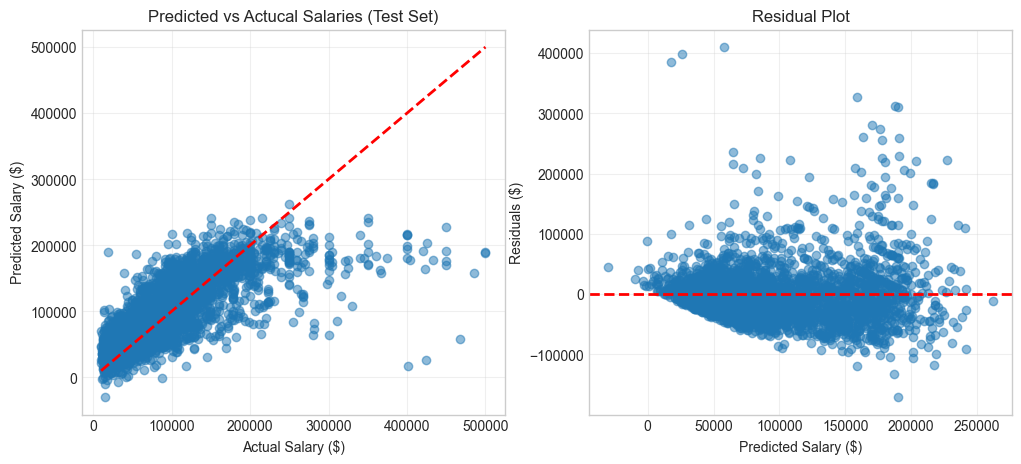

In [44]:
#1. Residual plot - check for patterns 
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_test,y_pred_test,alpha=0.5)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Salary ($)')
plt.ylabel('Predicted Salary ($)')
plt.title('Predicted vs Actucal Salaries (Test Set)')
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
residuals=y_test - y_pred_test
plt.scatter(y_pred_test,residuals,alpha=0.5)
plt.axhline(y=0,color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Salary ($)')
plt.ylabel('Residuals ($)')
plt.title('Residual Plot')
plt.grid(alpha=0.3)

plt.tight_layout
plt.show()

In [45]:
#2. Show All significant coefficient 
coefficients_sorted = coefficients.sort_values('Coefficient',ascending=False)

print("\n=== TOP 20 POSITIVE COEFICIENTS (Increase Salary) ===")
print(coefficients_sorted.head(20)[['Feature','Coefficient']].to_string(index=False))

print("\n=== TOP 20 NEGATIVE COEFFICIENTS (Decrease Salary) ===")
print(coefficients_sorted.tail(20)[['Feature','Coefficient']].to_string(index=False)) 


=== TOP 20 POSITIVE COEFICIENTS (Increase Salary) ===
                                     Feature  Coefficient
            Country_United States of America 59562.392994
DevType_Senior Executive (C-Suite, VP, etc.) 35465.798254
                         Country_Switzerland 32830.057374
                 DevType_Engineering manager 24000.300494
             DevType_Other (please specify): 12687.620722
                               Has_Terraform  8036.616004
                 Industry_Financial Services  7517.019573
                              Has_TypeScript  6462.364499
                               DevType_Other  6331.101022
                              Has_Kubernetes  5853.967723
                                      Has_Go  5788.901417
                                    Has_Rust  5778.340980
                   DevType_Developer, mobile  5773.974621
                                   Has_React  5696.921818
                                     Has_AWS  4975.244767
                 

In [46]:
# 3. Feature categories breakdown
print("\n=== COEFFICIENT BREAKDOWN BY CATEGORY ===")

#Country features
country_coefs = coefficients[coefficients['Feature'].str.startswith('Country_')]
print(f"\nCountry features - Average absolute impact: ${country_coefs['Abs_Coefficient'].mean():,.2f}")

#Skills (Has_*)
skill_coefs =coefficients[coefficients['Feature'].str.startswith('Has_')]
print(f"Skill features - Average absolute impact: ${skill_coefs['Abs_Coefficient'].mean():,.2f}")

# DevType features 
devtype_coefs =coefficients[coefficients['Feature'].str.startswith('DevType_')]
print(f"DevType features - Average absolute impact: ${devtype_coefs['Abs_Coefficient'].mean():,.2f}")

# Industry features
industry_coefs = coefficients[coefficients['Feature'].str.startswith('Industry_')]
print(f"Industry features - Average absolute impact: ${industry_coefs['Abs_Coefficient'].mean():,.2f}")


=== COEFFICIENT BREAKDOWN BY CATEGORY ===

Country features - Average absolute impact: $32,695.99
Skill features - Average absolute impact: $4,045.76
DevType features - Average absolute impact: $10,949.80
Industry features - Average absolute impact: $7,055.26


In [47]:
#Check if model struggles with high earners 
salary_ranges = pd.DataFrame({
    'Actual':y_test,
    'Predicted': y_pred_test,
    'Error': abs(y_test - y_pred_test)
})

salary_ranges['Salary_Range'] = pd.cut(salary_ranges['Actual'],
                                       bins=[0,50000,100000,150000,200000,500000],
                                       labels=['<$50k','$50-100k','$100-150k','$150-200k','>$200k'])
print("=== ERROR BY SALARY RANGE ===")
error_by_range=salary_ranges.groupby('Salary_Range')['Error'].agg(['mean','median','count'])
print(error_by_range)

=== ERROR BY SALARY RANGE ===
                       mean        median  count
Salary_Range                                    
<$50k          23261.927101  19276.421300    743
$50-100k       22881.992738  17467.635147   1138
$100-150k      29042.150790  25957.055675    603
$150-200k      28604.577761  20566.543914    323
>$200k        102430.279660  81974.239614    206



=== FACTORS YOU CAN CONTROL ===

Top 15 ways to increase your salary:
                                     Feature  Coefficient
DevType_Senior Executive (C-Suite, VP, etc.) 35465.798254
                 DevType_Engineering manager 24000.300494
             DevType_Other (please specify): 12687.620722
                               Has_Terraform  8036.616004
                              Has_TypeScript  6462.364499
                               DevType_Other  6331.101022
                              Has_Kubernetes  5853.967723
                                      Has_Go  5788.901417
                                    Has_Rust  5778.340980
                   DevType_Developer, mobile  5773.974621
                                   Has_React  5696.921818
                                     Has_AWS  4975.244767
                                  Has_Kotlin  4538.840390
                             OrgSize_Ordinal  4477.856114
                                   Has_Redis  4106.935926


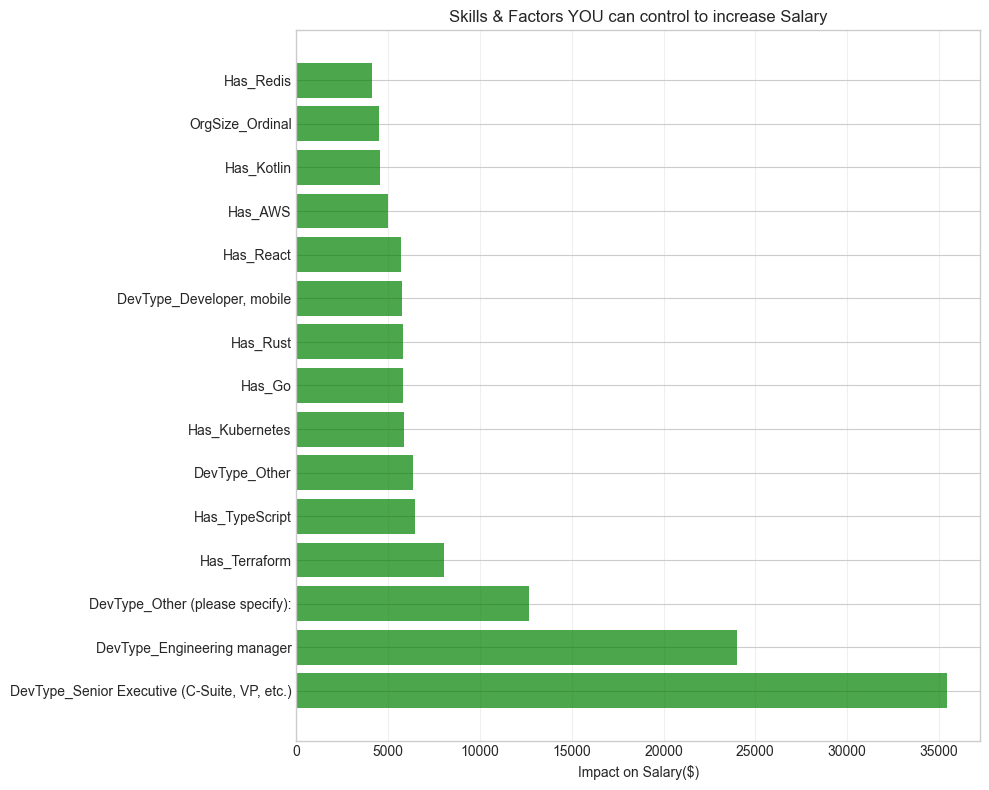

In [48]:
#Show the skilld/factors you can control 
controllable_features =coefficients[
    (coefficients['Feature'].str.startswith('Has_')) |
    (coefficients['Feature'].str.startswith('DevType_')) |
    (coefficients['Feature']=='YearsCodePro') |
    (coefficients['Feature']=='OrgSize_Ordinal') |
     (coefficients['Feature'].str.startswith('RemoteWork_')) 
    ].copy()
controllable_features=controllable_features.sort_values('Coefficient',ascending=False)

print("\n=== FACTORS YOU CAN CONTROL ===")
print("\nTop 15 ways to increase your salary:")
print(controllable_features.head(15)[['Feature','Coefficient']].to_string(index=False))

#Visualize it 
plt.figure(figsize=(10,8))
top_controllable = controllable_features.head(15)
colors =['green' if x>0 else 'red' for x in top_controllable['Coefficient']]

plt.barh(range(len(top_controllable)), top_controllable['Coefficient'],color = colors, alpha=0.7)
plt.yticks(range(len(top_controllable)), top_controllable['Feature'], fontsize = 10)
plt.xlabel('Impact on Salary($)')
plt.title('Skills & Factors YOU can control to increase Salary')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
    

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print('All libraries loaded successfully ✓')

All libraries loaded successfully ✓


In [50]:
df = pd.read_csv('survey_results_slim.csv')

print(f'Dataset shape: {df.shape}')
print(f'\nColumn overview:')
print(df.dtypes.value_counts())
print(f'\nSalary statistics (raw):')
print(df['ConvertedCompYearly'].describe())

Dataset shape: (48019, 33)

Column overview:
object     31
float64     2
Name: count, dtype: int64

Salary statistics (raw):
count    4.801900e+04
mean     1.031101e+05
std      6.814188e+05
min      1.000000e+00
25%      4.390700e+04
50%      7.496300e+04
75%      1.216410e+05
max      7.435143e+07
Name: ConvertedCompYearly, dtype: float64


Rows after salary filter: 44,555 (92.8% of original)


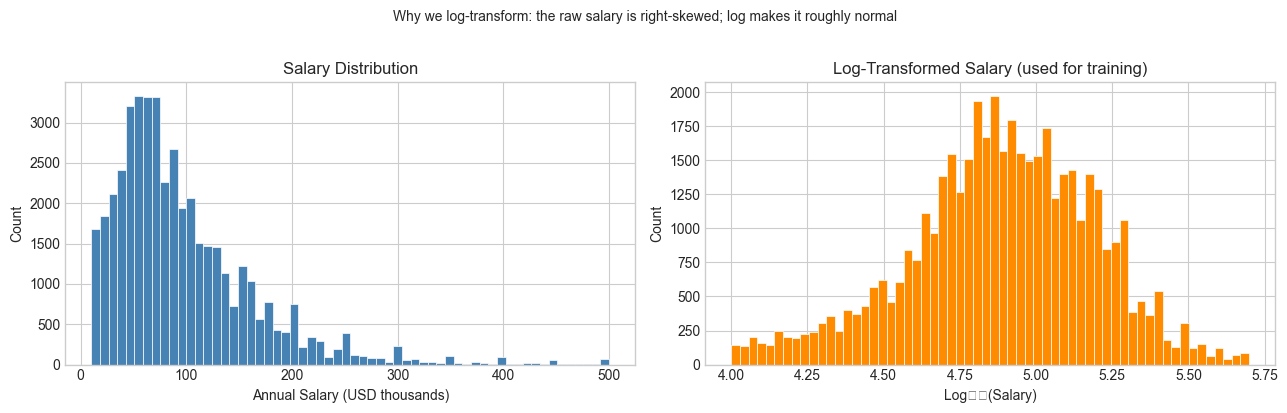

In [51]:
# ── Salary outlier filtering ────────────────────────────────────────────────
# Keep salaries between $10k–$500k USD (realistic dev range, removes data entry errors)
df_clean = df[
    (df['ConvertedCompYearly'] >= 10_000) &
    (df['ConvertedCompYearly'] <= 500_000)
].copy()

print(f'Rows after salary filter: {len(df_clean):,} '
      f'({len(df_clean)/len(df)*100:.1f}% of original)')

# ── Visualize salary distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_clean['ConvertedCompYearly'] / 1000, bins=60,
             color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Annual Salary (USD thousands)')
axes[0].set_ylabel('Count')
axes[0].set_title('Salary Distribution')

axes[1].hist(np.log10(df_clean['ConvertedCompYearly']), bins=60,
             color='darkorange', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Log₁₀(Salary)')
axes[1].set_ylabel('Count')
axes[1].set_title('Log-Transformed Salary (used for training)')

plt.suptitle('Why we log-transform: the raw salary is right-skewed;'
             ' log makes it roughly normal', fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

In [52]:
df_feat = df_clean.copy()

# ── 4a. Ordinal encodings ────────────────────────────────────────────────────
age_order = {
    'Under 18 years old': 0, '18-24 years old': 1, '25-34 years old': 2,
    '35-44 years old': 3, '45-54 years old': 4, '55-64 years old': 5,
    '65 years or older': 6, 'Prefer not to say': 2
}
ed_order = {
    'Primary/elementary school': 0,
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 1,
    'Some college/university study without earning a degree': 2,
    'Associate degree (A.A., A.S., etc.)': 3,
    'Bachelor\u2019s degree (B.A., B.S., B.Eng., etc.)': 4,
    'Master\u2019s degree (M.A., M.S., M.Eng., MBA, etc.)': 5,
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 6,
    'Something else': 2
}
org_order = {
    'Just me - I am a freelancer, sole proprietor, etc.': 0,
    '2 to 9 employees': 1, '10 to 19 employees': 2,
    '20 to 99 employees': 3, '100 to 499 employees': 4,
    '500 to 999 employees': 5, '1,000 to 4,999 employees': 6,
    '5,000 to 9,999 employees': 7, '10,000 or more employees': 8,
    "I don\u2019t know": 4
}

df_feat['Age_Ordinal']     = df_feat['Age'].map(age_order)
df_feat['EdLevel_Ordinal'] = df_feat['EdLevel'].map(ed_order)
df_feat['OrgSize_Ordinal'] = df_feat['OrgSize'].map(org_order)
df_feat['YearsCodePro']    = pd.to_numeric(df_feat['YearsCodePro'], errors='coerce')

# ── 4b. Country grouping — top 30 + 'Other' ─────────────────────────────────
TOP_N_COUNTRIES = 30
top_countries = df_feat['Country'].value_counts().head(TOP_N_COUNTRIES).index.tolist()
df_feat['Country_Grouped'] = df_feat['Country'].apply(
    lambda x: x if x in top_countries else 'Other'
)
print(f'Country groups: {df_feat["Country_Grouped"].nunique()} '
      f'(top {TOP_N_COUNTRIES} + Other)')

# ── 4c. DevType grouping — top 15 + 'Other' ─────────────────────────────────
TOP_N_DEVTYPES = 15
top_devtypes = df_feat['DevType'].value_counts().head(TOP_N_DEVTYPES).index.tolist()
df_feat['DevType_Grouped'] = df_feat['DevType'].apply(
    lambda x: x if x in top_devtypes else 'Other'
)
print(f'DevType groups: {df_feat["DevType_Grouped"].nunique()}')

# ── 4d. Binary skill features ────────────────────────────────────────────────
# Languages
languages = ['Python', 'JavaScript', 'TypeScript', 'Java', 'Go',
             'Rust', 'Scala', 'Kotlin', 'Swift', 'C#', 'SQL',
             'PHP', 'Ruby', 'C\+\+', 'Bash/Shell']
for lang in languages:
    col_name = f'Lang_{lang.replace("+", "P").replace("/", "_").replace(".", "")}'
    df_feat[col_name] = df_feat['LanguageHaveWorkedWith'].str.contains(
        lang, na=False, regex=True).astype(int)

# Databases
databases = ['PostgreSQL', 'MongoDB', 'Redis', 'MySQL',
             'Microsoft SQL Server', 'Elasticsearch', 'SQLite']
for db in databases:
    df_feat[f'DB_{db.replace(" ", "_")}'] = df_feat['DatabaseHaveWorkedWith'].str.contains(
        db, na=False).astype(int)

# Cloud
clouds = {'AWS': 'Amazon Web Services', 'Azure': 'Azure', 'GCP': 'Google Cloud'}
for key, pattern in clouds.items():
    df_feat[f'Cloud_{key}'] = df_feat['PlatformHaveWorkedWith'].str.contains(
        pattern, na=False).astype(int)

# DevOps tools
tools = ['Docker', 'Kubernetes', 'Terraform']
for tool in tools:
    df_feat[f'Tool_{tool}'] = df_feat['ToolsTechHaveWorkedWith'].str.contains(
        tool, na=False).astype(int)

# Web frameworks
frameworks = ['React', 'Next\\.js', 'Node\\.js', 'Vue\\.js',
              'Angular', 'Spring Boot', 'Django', 'FastAPI']
for fw in frameworks:
    col = f'FW_{fw.replace(".", "").replace("\\\\", "").replace(".", "").replace(" ", "_")}'
    df_feat[col] = df_feat['WebframeHaveWorkedWith'].str.contains(
        fw, na=False, regex=True).astype(int)

skill_cols = [c for c in df_feat.columns if c.startswith(('Lang_', 'DB_', 'Cloud_', 'Tool_', 'FW_'))]
print(f'\nBinary skill features created: {len(skill_cols)}')

# ── 4e. One-hot encode remaining categoricals ───────────────────────────────
ohe_cols = ['RemoteWork', 'AISelect', 'MainBranch', 'Industry',
            'Country_Grouped', 'DevType_Grouped']
df_feat = pd.get_dummies(df_feat, columns=ohe_cols, drop_first=True)

print(f'\nTotal features available: {df_feat.shape[1]}')

Country groups: 31 (top 30 + Other)
DevType groups: 16

Binary skill features created: 36

Total features available: 129


In [53]:
# ── Build final feature matrix ───────────────────────────────────────────────
base_cols = ['YearsCodePro', 'Age_Ordinal', 'EdLevel_Ordinal', 'OrgSize_Ordinal']
auto_cols = [c for c in df_feat.columns
             if c.startswith(('Lang_', 'DB_', 'Cloud_', 'Tool_', 'FW_',
                              'RemoteWork_', 'AISelect_', 'MainBranch_',
                              'Industry_', 'Country_Grouped_', 'DevType_Grouped_'))]

FEATURE_COLS = base_cols + auto_cols

df_model = df_feat[FEATURE_COLS + ['ConvertedCompYearly']].dropna()

print(f'Final modelling dataset: {df_model.shape[0]:,} rows × {len(FEATURE_COLS)} features')
print(f'Rows retained: {len(df_model)/len(df)*100:.1f}% of original survey')

Final modelling dataset: 43,407 rows × 101 features
Rows retained: 90.4% of original survey


In [54]:
X = df_model[FEATURE_COLS]
y_raw = df_model['ConvertedCompYearly']

# Log-transform the target — makes the model predict proportional changes in salary
# (i.e. errors are treated as % off, not dollar off — much fairer across salary ranges)
y = np.log1p(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set:  {X_train.shape[0]:,} rows')
print(f'Test set:      {X_test.shape[0]:,} rows')

Training set:  34,725 rows
Test set:      8,682 rows


In [55]:
# ── Train GBM ───────────────────────────────────────────────────────────────
# Hyperparameters:
#   n_estimators=300  → more trees = better fit (with diminishing returns)
#   max_depth=5       → allows interaction up to 5 features deep
#   learning_rate=0.08 → smaller steps = more robust generalization
#   subsample=0.8     → use 80% of rows per tree (reduces overfitting)
#   min_samples_leaf=20 → each leaf needs ≥20 samples (prevents overfitting on rare combos)

model = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    min_samples_leaf=20,
    random_state=42
)

print('Training model... (takes ~60 seconds)')
model.fit(X_train, y_train)
print('Done ✓')

Training model... (takes ~60 seconds)
Done ✓


In [56]:
# Predict on both splits
y_pred_train = np.expm1(model.predict(X_train))  # undo log transform
y_pred_test  = np.expm1(model.predict(X_test))
y_actual_train = np.expm1(y_train)
y_actual_test  = np.expm1(y_test)

# ── Metrics ─────────────────────────────────────────────────────────────────
r2_train  = r2_score(y_actual_train, y_pred_train)
r2_test   = r2_score(y_actual_test,  y_pred_test)
mae_train = mean_absolute_error(y_actual_train, y_pred_train)
mae_test  = mean_absolute_error(y_actual_test,  y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_actual_test, y_pred_test))

# Median absolute % error — most interpretable
pct_errors = np.abs(y_actual_test - y_pred_test) / y_actual_test * 100
median_pct_error = np.median(pct_errors)

print('=' * 55)
print('             MODEL PERFORMANCE SUMMARY')
print('=' * 55)
print(f'  R² (Train):                {r2_train:.4f}')
print(f'  R² (Test):                 {r2_test:.4f}   ← explains {r2_test*100:.1f}% of salary variance')
print(f'  MAE (Test):            ${mae_test:>10,.0f}')
print(f'  RMSE (Test):           ${rmse_test:>10,.0f}')
print(f'  Median % Error (Test):   {median_pct_error:.1f}%   ← typical prediction is off by this much')
print('=' * 55)
print()
print(f'  Overfitting gap (R² train-test):  {r2_train - r2_test:.4f}')
print('  (< 0.05 is great, < 0.10 is acceptable)')

             MODEL PERFORMANCE SUMMARY
  R² (Train):                0.6134
  R² (Test):                 0.5723   ← explains 57.2% of salary variance
  MAE (Test):            $    27,463
  RMSE (Test):           $    45,245
  Median % Error (Test):   22.2%   ← typical prediction is off by this much

  Overfitting gap (R² train-test):  0.0411
  (< 0.05 is great, < 0.10 is acceptable)


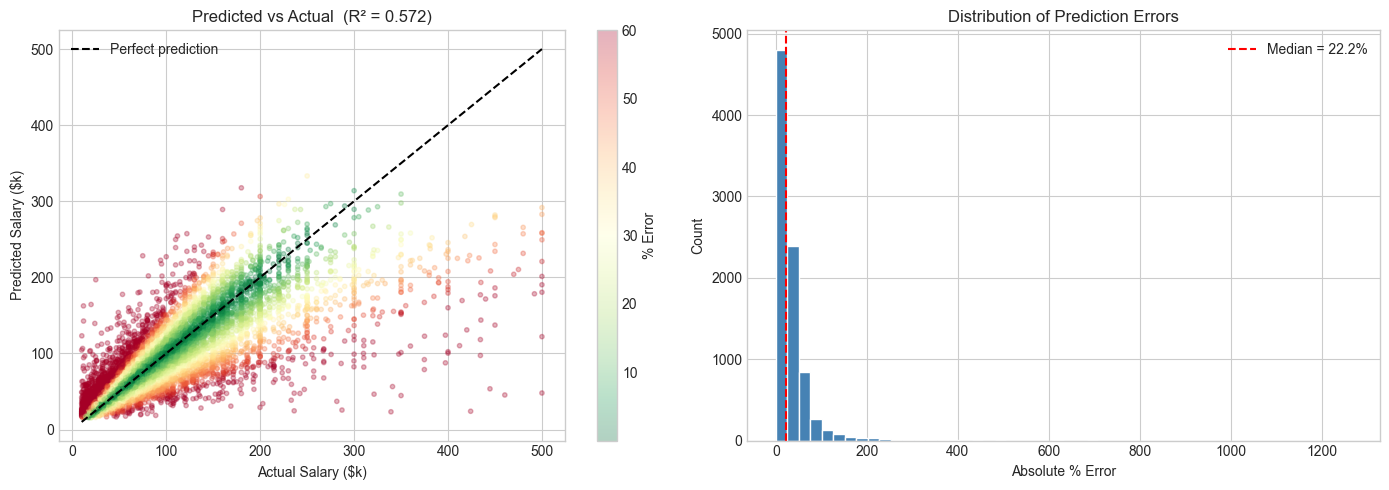

In [57]:
# ── Predicted vs Actual plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted vs actual
sc = axes[0].scatter(y_actual_test / 1000, y_pred_test / 1000,
                     alpha=0.3, s=10, c=pct_errors, cmap='RdYlGn_r', vmax=60)
axes[0].plot([10, 500], [10, 500], 'k--', lw=1.5, label='Perfect prediction')
plt.colorbar(sc, ax=axes[0], label='% Error')
axes[0].set_xlabel('Actual Salary ($k)')
axes[0].set_ylabel('Predicted Salary ($k)')
axes[0].set_title(f'Predicted vs Actual  (R² = {r2_test:.3f})')
axes[0].legend()

# Histogram: prediction error
axes[1].hist(pct_errors, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(median_pct_error, color='red', linestyle='--',
                label=f'Median = {median_pct_error:.1f}%')
axes[1].set_xlabel('Absolute % Error')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Prediction Errors')
axes[1].legend()

plt.tight_layout()
plt.show()

In [58]:
# ── Error by salary range ────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'Actual': y_actual_test,
    'Predicted': y_pred_test,
    'AbsError': np.abs(y_actual_test - y_pred_test),
    'PctError': pct_errors
})
results_df['Range'] = pd.cut(
    results_df['Actual'],
    bins=[0, 50_000, 100_000, 150_000, 200_000, 500_001],
    labels=['<$50k', '$50–100k', '$100–150k', '$150–200k', '>$200k']
)

print('Error breakdown by salary range:')
print(results_df.groupby('Range', observed=True)[['AbsError', 'PctError']].agg(
    MeanAbsError=('AbsError', lambda x: f'${x.mean():,.0f}'),
    MedianPctError=('PctError', lambda x: f'{x.median():.1f}%'),
    Count=('AbsError', 'count')
).to_string())

Error breakdown by salary range:
          MeanAbsError MedianPctError  Count
Range                                       
<$50k          $15,135          34.8%   2089
$50–100k       $16,674          17.5%   3344
$100–150k      $29,585          20.8%   1670
$150–200k      $39,295          18.1%    986
>$200k        $106,087          34.4%    593


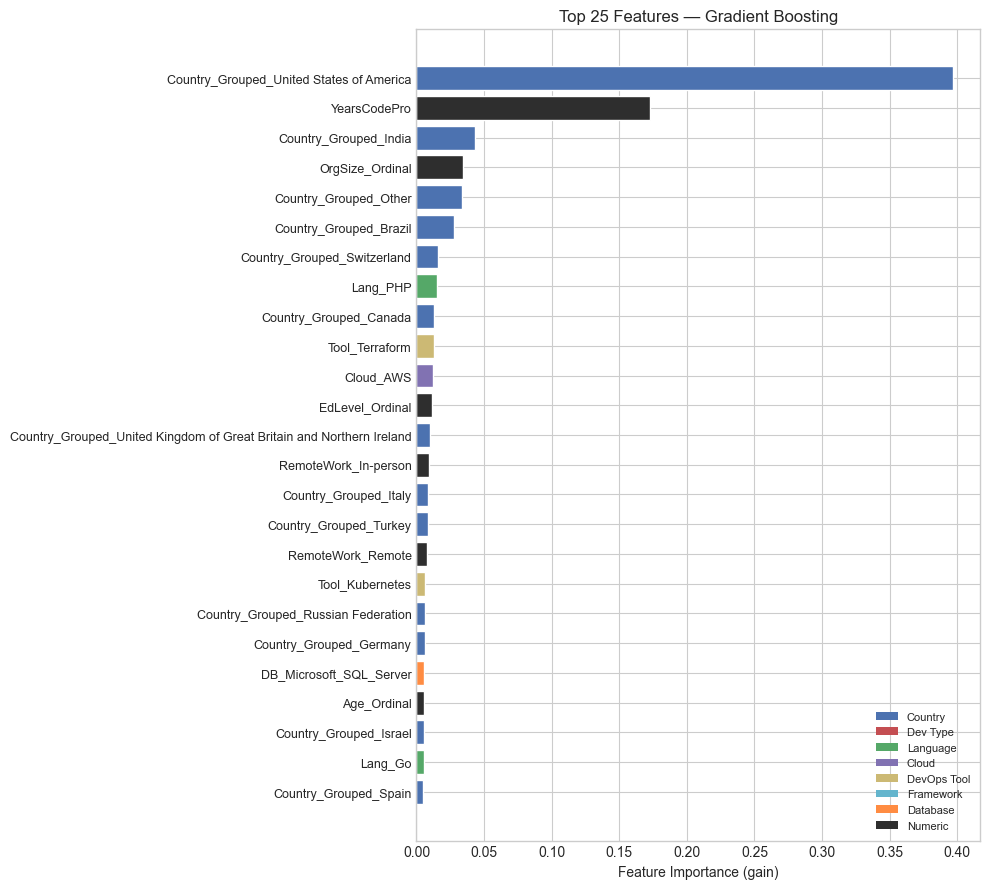

In [59]:
importance_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

# ── Top 25 features ──────────────────────────────────────────────────────────
top_n = 25
top_imp = importance_df.head(top_n)

# Color by category
def cat_color(name):
    if name.startswith('Country_'):  return '#4C72B0'
    if name.startswith('Lang_'):     return '#55A868'
    if name.startswith('DevType_'):  return '#C44E52'
    if name.startswith('Cloud_'):    return '#8172B2'
    if name.startswith('Tool_'):     return '#CCB974'
    if name.startswith('FW_'):       return '#64B5CD'
    if name.startswith('DB_'):       return '#FF8C42'
    if name.startswith('Industry_'): return '#A0A0A0'
    return '#2E2E2E'

colors = [cat_color(f) for f in top_imp['Feature']]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(range(top_n), top_imp['Importance'].values, color=colors, edgecolor='white')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_imp['Feature'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (gain)')
ax.set_title(f'Top {top_n} Features — Gradient Boosting')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='Country'),
    Patch(facecolor='#C44E52', label='Dev Type'),
    Patch(facecolor='#55A868', label='Language'),
    Patch(facecolor='#8172B2', label='Cloud'),
    Patch(facecolor='#CCB974', label='DevOps Tool'),
    Patch(facecolor='#64B5CD', label='Framework'),
    Patch(facecolor='#FF8C42', label='Database'),
    Patch(facecolor='#2E2E2E', label='Numeric'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

In [60]:
# Save the model + metadata needed for prediction
model_data = {
    'model': model,
    'feature_cols': FEATURE_COLS,
    'top_countries': top_countries,
    'top_devtypes': top_devtypes,
    'age_order': age_order,
    'ed_order': ed_order,
    'org_order': org_order,
}

with open('salary_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print('Model saved to salary_model.pkl ✓')
print(f'File size: {os.path.getsize("salary_model.pkl") / 1024 / 1024:.1f} MB')

Model saved to salary_model.pkl ✓
File size: 1.1 MB


In [64]:
# ═══════════════════════════════════════════════════════════════════
#  QUICK PREDICTION — edit values here and run
# ═══════════════════════════════════════════════════════════════════

import pickle, numpy as np, pandas as pd

with open('salary_model.pkl', 'rb') as f:
    saved = pickle.load(f)
m, feat_cols = saved['model'], saved['feature_cols']

# ─── EDIT BELOW ────────────────────────────────────────────────────
inputs = dict(
    # ── Background ──────────────────────────────────────────────────
    # Country options: 'United States of America', 'Germany', 'United Kingdom of Great Britain and Northern Ireland',
    # 'Canada', 'India', 'France', 'Netherlands', 'Poland', 'Brazil', 'Australia', 'Spain', 'Sweden',
    # 'Italy', 'Switzerland', 'Austria', 'Denmark', 'Czech Republic', 'Norway', 'Portugal', ,
    # 'Belgium', 'Finland', 'Russian Federation', 'Ukraine', 'New Zealand', 'Romania', 'Turkey',
    # 'South Africa', 'Greece', 'Mexico', or 'Other'
    country          = 'UAE',

    # DevType options: 'Full-stack developer', 'Back-end developer', 'Front-end developer',
    # 'Full-stack developer;Back-end developer', 'Mobile developer', 'DevOps specialist',
    # 'Data scientist or machine learning specialist', 'Cloud infrastructure engineer',
    # 'Security professional', 'Site reliability engineer', or 'Other'
    devtype          = 'Full-stack developer',

    # Education: 0=Primary, 1=Secondary, 2=Some college, 3=Associate, 4=Bachelor, 5=Master, 6=PhD
    ed_level         = 4,

    years_code_pro   = 5,        # Years of professional experience

    # Age: 0=Under 18, 1=18-24, 2=25-34, 3=35-44, 4=45-54, 5=55-64, 6=65+
    age              = 2,

    # OrgSize: 0=Solo freelancer, 1=2-9, 2=10-19, 3=20-99, 4=100-499, 5=500-999,
    #          6=1000-4999, 7=5000-9999, 8=10000+
    org_size         = 4,

    # ── Languages (1=yes, 0=no) ───────────────────────────────────────
    Python=1, JavaScript=1, TypeScript=1, Java=0, Go=0,
    Rust=0, Scala=0, Kotlin=0, Swift=0, CSharp=0, SQL=1,
    PHP=0, Ruby=0, CPP=0, BashShell=1,

    # ── Databases ─────────────────────────────────────────────────────
    PostgreSQL=1, MongoDB=0, Redis=1, MySQL=0,
    MicrosoftSQLServer=0, Elasticsearch=0, SQLite=0,

    # ── Cloud ──────────────────────────────────────────────────────────
    AWS=1, Azure=0, GCP=0,

    # ── DevOps ─────────────────────────────────────────────────────────
    Docker=1, Kubernetes=0, Terraform=0,

    # ── Frameworks ─────────────────────────────────────────────────────
    React=1, NextJS=0, NodeJS=1, VueJS=0,
    Angular=0, SpringBoot=0, Django=0, FastAPI=0,
)
# ─── STOP EDITING ───────────────────────────────────────────────────

# Build row
top_c  = saved['top_countries']
top_d  = saved['top_devtypes']
cg = inputs['country']  if inputs['country']  in top_c else 'Other'
dg = inputs['devtype']  if inputs['devtype']   in top_d else 'Other'

row = {col: 0 for col in feat_cols}
row['YearsCodePro']    = inputs['years_code_pro']
row['Age_Ordinal']     = inputs['age']
row['EdLevel_Ordinal'] = inputs['ed_level']
row['OrgSize_Ordinal'] = inputs['org_size']

skill_map = {
    'Lang_Python':             inputs['Python'],
    'Lang_JavaScript':         inputs['JavaScript'],
    'Lang_TypeScript':         inputs['TypeScript'],
    'Lang_Java':               inputs['Java'],
    'Lang_Go':                 inputs['Go'],
    'Lang_Rust':               inputs['Rust'],
    'Lang_Scala':              inputs['Scala'],
    'Lang_Kotlin':             inputs['Kotlin'],
    'Lang_Swift':              inputs['Swift'],
    'Lang_C#':                 inputs['CSharp'],
    'Lang_SQL':                inputs['SQL'],
    'Lang_PHP':                inputs['PHP'],
    'Lang_Ruby':               inputs['Ruby'],
    'Lang_CPP':                inputs['CPP'],
    'Lang_Bash_Shell':         inputs['BashShell'],
    'DB_PostgreSQL':           inputs['PostgreSQL'],
    'DB_MongoDB':              inputs['MongoDB'],
    'DB_Redis':                inputs['Redis'],
    'DB_MySQL':                inputs['MySQL'],
    'DB_Microsoft_SQL_Server': inputs['MicrosoftSQLServer'],
    'DB_Elasticsearch':        inputs['Elasticsearch'],
    'DB_SQLite':               inputs['SQLite'],
    'Cloud_AWS':               inputs['AWS'],
    'Cloud_Azure':             inputs['Azure'],
    'Cloud_GCP':               inputs['GCP'],
    'Tool_Docker':             inputs['Docker'],
    'Tool_Kubernetes':         inputs['Kubernetes'],
    'Tool_Terraform':          inputs['Terraform'],
    'FW_React':                inputs['React'],
    'FW_Nextjs':               inputs['NextJS'],
    'FW_Nodejs':               inputs['NodeJS'],
    'FW_Vuejs':                inputs['VueJS'],
    'FW_Angular':              inputs['Angular'],
    'FW_Spring_Boot':          inputs['SpringBoot'],
    'FW_Django':               inputs['Django'],
    'FW_FastAPI':              inputs['FastAPI'],
}
for k, v in skill_map.items():
    if k in row: row[k] = v

if f'Country_Grouped_{cg}' in row:  row[f'Country_Grouped_{cg}'] = 1
if f'DevType_Grouped_{dg}' in row:  row[f'DevType_Grouped_{dg}'] = 1

X_in = pd.DataFrame([row])[feat_cols]
pred  = np.expm1(m.predict(X_in)[0])
low   = pred * 0.75
high  = pred * 1.25

print(f'\n  Role:     {inputs["devtype"]}')
print(f'  Country:  {inputs["country"]}')
print(f'  Exp:      {inputs["years_code_pro"]} years')
print()
print(f'  💰 Predicted Salary:  ${pred:>12,.0f} / year (USD)')
print(f'     Likely Range:      ${low:>12,.0f}  –  ${high:,.0f}')


  Role:     Full-stack developer
  Country:  UAE
  Exp:      5 years

  💰 Predicted Salary:  $      51,725 / year (USD)
     Likely Range:      $      38,793  –  $64,656
